# Week 3 — EDA & Feature Engineering
**Project:** Drug Side Effect Predictor  
**Goal:** Understand the label space visually, then build the final feature matrices X_train and X_test ready for modeling.

**Decisions locked in from Week 2:**
- 1,117 drugs, 845 side effect labels (threshold ≥25 drugs)
- Train: 893 drugs / Test: 224 drugs (80/20 drug-level split, random_state=42)

**Decisions locked in for this week:**
- ATC encoding: 3-character subgroup level (~100 categories), MultiLabelBinarizer, deduplicated per drug
- TF-IDF: 200 features, fit on train only
- `stitch_id_flat` kept as index (not a feature); `drug_name` dropped from X

## Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import sparse
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

# ── Paths ────────────────────────────────────────────────────────────────────
SPLITS    = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\data\splits\\"
PROCESSED = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\data\processed\\"
FIGURES   = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\figures\\"
ENCODERS  = r"D:\Experimental Stuff\Data Science\Drug-Side-Effect-Predictor\models\encoders\\"

# Create output folders if they don't exist
for folder in [FIGURES, ENCODERS]:
    os.makedirs(folder, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded.")

Libraries loaded.


## Load train and test splits

In [2]:
train_df = pd.read_csv(SPLITS + "train.csv")
test_df  = pd.read_csv(SPLITS + "test.csv")

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

# Identify attribute columns vs label columns
ATTR_COLS  = ["stitch_id_flat", "drug_name", "atc_codes", "indications_text"]
LABEL_COLS = [c for c in train_df.columns if c not in ATTR_COLS]

print(f"\nAttribute columns: {len(ATTR_COLS)}")
print(f"Label columns:     {len(LABEL_COLS)}")

Train shape: (893, 849)
Test shape:  (224, 849)

Attribute columns: 4
Label columns:     845


---
## Step 3.1 — Side-effect frequency distribution

Two plots:
1. **Top-30 most common side effects** — bar chart of how many drugs in the training set have each side effect
2. **Label cardinality distribution** — histogram of how many side effects each drug has

We use the **training set only** for all EDA. Looking at the test set before modeling would constitute data leakage.

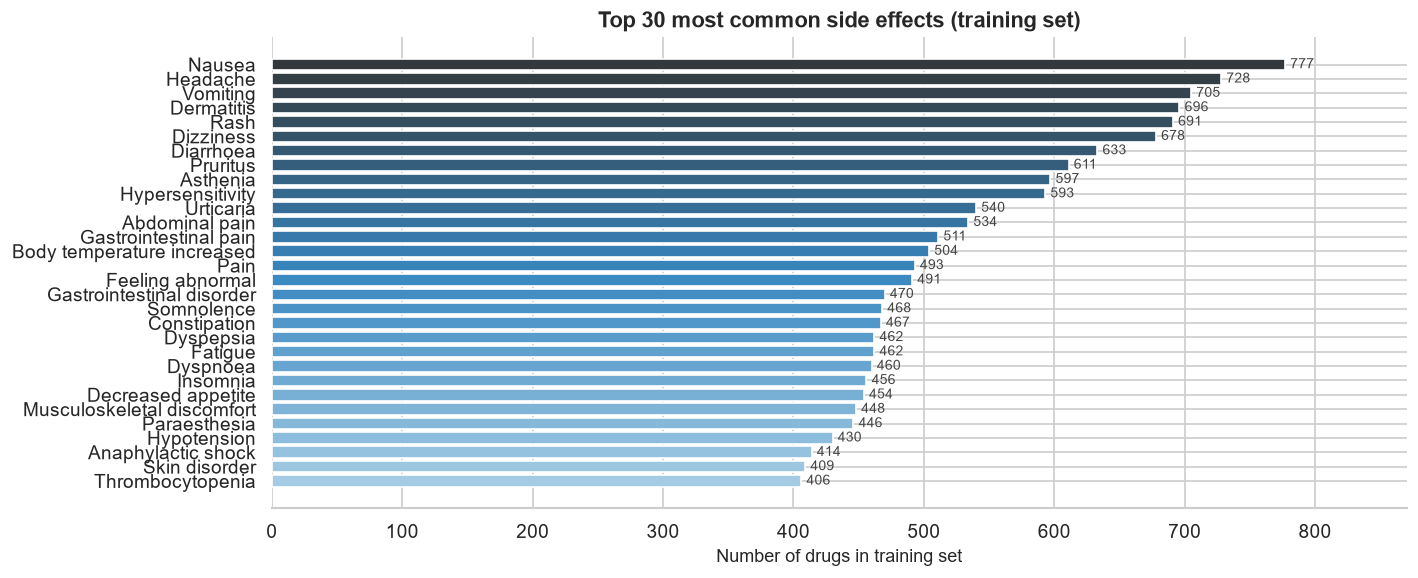

Saved: figures/3.1a_top30_side_effects.png


In [3]:
# ── Side effect prevalence across training drugs ──────────────────────────────
se_prevalence = train_df[LABEL_COLS].sum().sort_values(ascending=False)

# Plot 1: Top-30 most common side effects
fig, ax = plt.subplots(figsize=(12, 5))

top30 = se_prevalence.head(30)
bars = ax.barh(
    top30.index[::-1],
    top30.values[::-1],
    color=sns.color_palette("Blues_d", 30)
)

# Annotate bar values
for bar, val in zip(bars, top30.values[::-1]):
    ax.text(val + 4, bar.get_y() + bar.get_height() / 2,
            str(int(val)), va="center", ha="left", fontsize=8.5, color="#444")

ax.set_xlabel("Number of drugs in training set", fontsize=11)
ax.set_title("Top 30 most common side effects (training set)", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}"))
ax.set_xlim(0, top30.max() * 1.12)
sns.despine(left=True)

plt.tight_layout()
plt.savefig(FIGURES + "3.1a_top30_side_effects.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/3.1a_top30_side_effects.png")

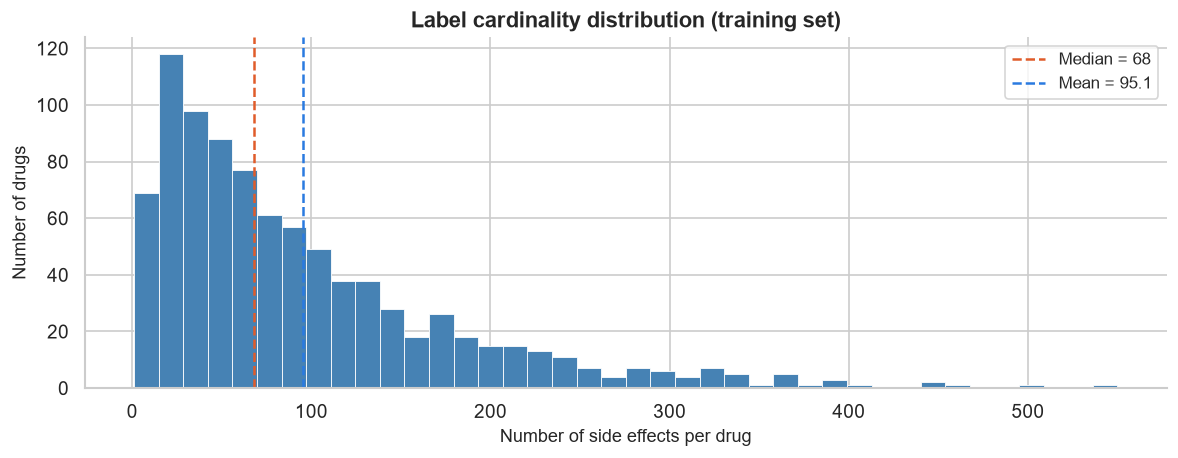

Median side effects per drug: 68
Mean side effects per drug:   95.1
Min: 1   Max: 550
Saved: figures/3.1b_label_cardinality.png


In [4]:
# Plot 2: Label cardinality — how many side effects does each drug have?
label_counts = train_df[LABEL_COLS].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(label_counts, bins=40, color="steelblue", edgecolor="white", linewidth=0.5)

median_val = label_counts.median()
mean_val   = label_counts.mean()

ax.axvline(median_val, color="#e05c2a", linestyle="--", linewidth=1.5,
           label=f"Median = {int(median_val)}")
ax.axvline(mean_val, color="#2a7ae0", linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_val:.1f}")

ax.set_xlabel("Number of side effects per drug", fontsize=11)
ax.set_ylabel("Number of drugs", fontsize=11)
ax.set_title("Label cardinality distribution (training set)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
sns.despine()

plt.tight_layout()
plt.savefig(FIGURES + "3.1b_label_cardinality.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Median side effects per drug: {int(median_val)}")
print(f"Mean side effects per drug:   {mean_val:.1f}")
print(f"Min: {label_counts.min()}   Max: {label_counts.max()}")
print("Saved: figures/3.1b_label_cardinality.png")

**What to look for:** The median here becomes K — the number of side effects we predict per drug in Week 4. The distribution shape tells us whether most drugs are average (bell curve) or whether a few drugs dominate (right skew).

---
## Step 3.2 — Side effects by ATC therapeutic class (heatmap)

We group drugs by their first ATC letter (anatomical group — 14 categories) and show the **top-20 most common side effects** across those groups.

Note: We use the first letter here (not the 3-char subgroup) purely for *visualisation* — 100 subgroups would make an unreadable heatmap. The actual encoding in Step 3.3 uses 3 characters.

In [5]:
# Extract the first ATC letter per drug (take the first code if multiple)
# This is for visualisation only — encoding uses 3 chars
def first_atc_letter(atc_codes_str):
    """Return the anatomical group letter from the first ATC code."""
    if pd.isna(atc_codes_str) or atc_codes_str == "":
        return "Unknown"
    first_code = atc_codes_str.split("|")[0].strip()
    return first_code[0].upper() if first_code else "Unknown"

# ATC anatomical group names (standard WHO labels)
ATC_GROUP_NAMES = {
    "A": "A – Alimentary",
    "B": "B – Blood",
    "C": "C – Cardiovascular",
    "D": "D – Dermatologicals",
    "G": "G – Genito-urinary",
    "H": "H – Hormones",
    "J": "J – Anti-infectives",
    "L": "L – Antineoplastic",
    "M": "M – Musculoskeletal",
    "N": "N – Nervous system",
    "P": "P – Antiparasitic",
    "R": "R – Respiratory",
    "S": "S – Sensory organs",
    "V": "V – Various",
}

train_plot = train_df.copy()
train_plot["atc_group"] = train_plot["atc_codes"].apply(first_atc_letter)
train_plot["atc_group"] = train_plot["atc_group"].map(ATC_GROUP_NAMES).fillna("Unknown")

print("Drugs per ATC anatomical group (training set):")
print(train_plot["atc_group"].value_counts())

Drugs per ATC anatomical group (training set):
atc_group
N – Nervous system     155
C – Cardiovascular     119
A – Alimentary         108
J – Anti-infectives     98
L – Antineoplastic      82
D – Dermatologicals     67
G – Genito-urinary      46
M – Musculoskeletal     43
R – Respiratory         38
V – Various             36
B – Blood               34
S – Sensory organs      29
H – Hormones            23
P – Antiparasitic       15
Name: count, dtype: int64


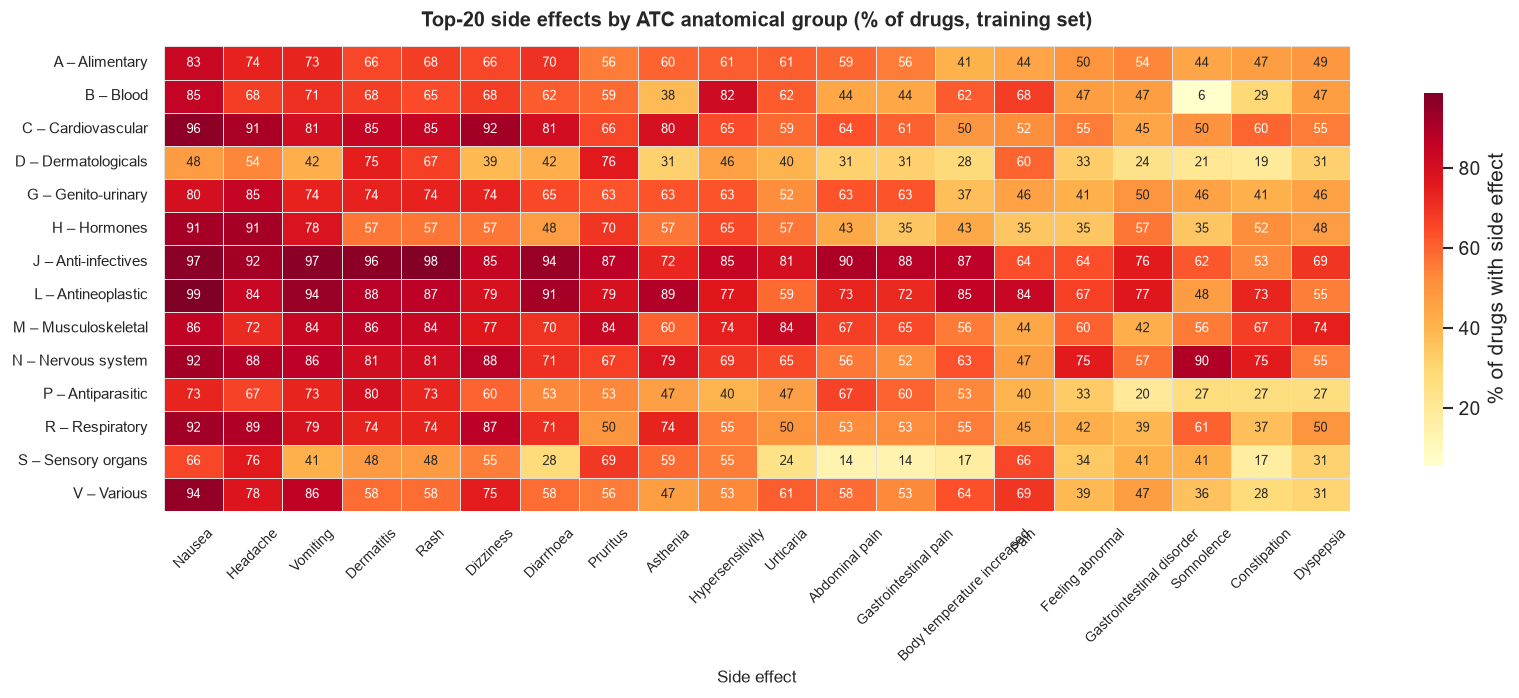

Saved: figures/3.2_atc_heatmap.png


In [6]:
# Top 20 side effects by overall prevalence (training set)
top20_se = se_prevalence.head(20).index.tolist()

# Mean prevalence of each top-20 side effect within each ATC group
heatmap_data = (
    train_plot
    .groupby("atc_group")[top20_se]
    .mean()
    .multiply(100)   # convert to percentage
)

# Drop groups with very few drugs (< 5) to avoid noisy rows
group_counts = train_plot["atc_group"].value_counts()
valid_groups = group_counts[group_counts >= 5].index
heatmap_data = heatmap_data.loc[heatmap_data.index.isin(valid_groups)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#e0e0e0",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 7.5},
    cbar_kws={"label": "% of drugs with side effect", "shrink": 0.8},
    ax=ax
)

ax.set_title("Top-20 side effects by ATC anatomical group (% of drugs, training set)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Side effect", fontsize=10)
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45, labelsize=8.5)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig(FIGURES + "3.2_atc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/3.2_atc_heatmap.png")

**What to look for:** Dark cells reveal drug-class-specific patterns — e.g. antineoplastic drugs (L) tend to cluster around nausea/vomiting, nervous-system drugs (N) around dizziness. These patterns are what the model should learn from ATC features.

---
## Step 3.3 — ATC code encoding (MultiLabelBinarizer, 3-char subgroup)

**Logic:**
1. Split each drug's pipe-separated ATC codes into a list
2. Slice each code to its first 3 characters (the therapeutic subgroup)
3. Deduplicate — if two codes collapse to the same subgroup, keep it once
4. Fit `MultiLabelBinarizer` on training data only
5. Transform both train and test

**Why MultiLabelBinarizer and not OneHotEncoder?**  
OneHotEncoder expects exactly one category per sample. Our drugs can have multiple ATC codes (and thus multiple subgroups). MultiLabelBinarizer handles variable-length sets of labels natively.

In [7]:
def parse_atc_subgroups(atc_codes_str):
    """
    Given a pipe-separated string of ATC codes, return a deduplicated
    sorted list of 3-character subgroup codes.
    
    Example:
        'V03AF03|V03AF04|L01XD04' -> ['L01', 'V03']
        NaN or '' -> ['UNKNOWN']
    """
    if pd.isna(atc_codes_str) or str(atc_codes_str).strip() == "":
        return ["UNKNOWN"]
    codes = atc_codes_str.split("|")
    subgroups = {c.strip()[:3].upper() for c in codes if len(c.strip()) >= 3}
    return sorted(subgroups) if subgroups else ["UNKNOWN"]


# Apply to both sets
train_atc_lists = train_df["atc_codes"].apply(parse_atc_subgroups)
test_atc_lists  = test_df["atc_codes"].apply(parse_atc_subgroups)

# Preview
print("Sample ATC subgroup lists (train):")
for name, subgroups in zip(train_df["drug_name"].head(5), train_atc_lists.head(5)):
    print(f"  {name:<30} -> {subgroups}")

Sample ATC subgroup lists (train):
  polythiazide                   -> ['C03']
  natamycin                      -> ['A01', 'A07', 'D01', 'G01', 'S01']
  lorazepam                      -> ['N05']
  rasburicase                    -> ['M04', 'V03']
  asenapine                      -> ['N05']


In [8]:
# Fit MLB on training data only — this is the leakage boundary
mlb = MultiLabelBinarizer(sparse_output=True)
X_atc_train = mlb.fit_transform(train_atc_lists)
X_atc_test  = mlb.transform(test_atc_lists)   # transform only — no fit

print(f"ATC feature matrix (train): {X_atc_train.shape}")
print(f"ATC feature matrix (test):  {X_atc_test.shape}")
print(f"Number of ATC subgroups:    {len(mlb.classes_)}")
print()
print("ATC subgroups discovered:", list(mlb.classes_))

# Save encoder
joblib.dump(mlb, ENCODERS + "mlb_atc.pkl")
print("\nEncoder saved: models/encoders/mlb_atc.pkl")

ATC feature matrix (train): (893, 82)
ATC feature matrix (test):  (224, 82)
Number of ATC subgroups:    82

ATC subgroups discovered: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A14', 'A16', 'B01', 'B02', 'B03', 'B05', 'B06', 'C01', 'C02', 'C03', 'C04', 'C05', 'C07', 'C08', 'C09', 'C10', 'D01', 'D03', 'D04', 'D05', 'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'G01', 'G02', 'G03', 'G04', 'H01', 'H02', 'H03', 'H05', 'J01', 'J02', 'J04', 'J05', 'L01', 'L02', 'L03', 'L04', 'M01', 'M02', 'M03', 'M04', 'M05', 'N01', 'N02', 'N03', 'N04', 'N05', 'N06', 'N07', 'P01', 'P02', 'P03', 'R01', 'R02', 'R03', 'R05', 'R06', 'R07', 'S01', 'S02', 'S03', 'V03', 'V04', 'V08', 'V09']

Encoder saved: models/encoders/mlb_atc.pkl


C:\Users\abdul\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_label.py:1016: UserWarning: unknown class(es) ['H04', 'V06'] will be ignored
  warnings.warn(


**Note on test-set unseen subgroups:** `MultiLabelBinarizer.transform()` silently ignores any ATC subgroup that appears in the test set but not in training. This is the correct behaviour — we cannot encode categories the model has never seen.

---
## Step 3.4 — TF-IDF encoding of `indications_text` (200 features)

**Settings:**
- `max_features=200` — keep the 200 highest-IDF terms
- `ngram_range=(1, 2)` — include bigrams (e.g. "renal failure" as one feature, not just "renal" and "failure" separately)
- `sublinear_tf=True` — dampen high raw term frequencies (standard practice for medical text)
- `min_df=3` — ignore terms appearing in fewer than 3 drugs (too rare to be useful)
- Fit on training data only; transform both sets

In [9]:
tfidf = TfidfVectorizer(
    max_features=200,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=3,
    strip_accents="unicode"
)

# Fill NaN with empty string (Week 2 already did this, but be defensive)
train_ind_text = train_df["indications_text"].fillna("").astype(str)
test_ind_text  = test_df["indications_text"].fillna("").astype(str)

# Fit on training text only
X_tfidf_train = tfidf.fit_transform(train_ind_text)
X_tfidf_test  = tfidf.transform(test_ind_text)

print(f"TF-IDF feature matrix (train): {X_tfidf_train.shape}")
print(f"TF-IDF feature matrix (test):  {X_tfidf_test.shape}")
print()

# Inspect top terms by IDF score (highest IDF = rarest = most discriminative)
feature_names = tfidf.get_feature_names_out()
idf_scores    = tfidf.idf_
top_idf_idx   = np.argsort(idf_scores)[::-1][:30]

print("Top 30 most discriminative TF-IDF terms (highest IDF):")
for i in top_idf_idx:
    print(f"  {feature_names[i]:<40} IDF={idf_scores[i]:.3f}")

# Save encoder
joblib.dump(tfidf, ENCODERS + "tfidf_indications.pkl")
print("\nEncoder saved: models/encoders/tfidf_indications.pkl")

TF-IDF feature matrix (train): (893, 200)
TF-IDF feature matrix (test):  (224, 200)

Top 30 most discriminative TF-IDF terms (highest IDF):
  candidiasis                              IDF=5.157
  hepatitis                                IDF=5.157
  tinea                                    IDF=5.088
  stage unspecified                        IDF=5.088
  lymphocyte                               IDF=5.088
  disease lymphocyte                       IDF=5.088
  type stage                               IDF=5.088
  hodgkin disease                          IDF=5.088
  bipolar disorder                         IDF=5.023
  density                                  IDF=5.023
  leukaemia acute                          IDF=5.023
  bipolar                                  IDF=5.023
  angle                                    IDF=4.962
  embolism                                 IDF=4.962
  erythema                                 IDF=4.962
  uterine                                  IDF=4.962
  unspecifie

---
## Step 3.5 — Stack features into final X matrices

We horizontally stack the two sparse feature matrices into one:

```
X = [ ATC subgroup columns | TF-IDF indication columns ]
    |  ~100 binary cols    |  200 float cols            |
```

Both matrices are already sparse (from `sparse_output=True` on the MLB and from `TfidfVectorizer`'s default output). `scipy.sparse.hstack` concatenates them without densifying — memory-efficient.

`stitch_id_flat` is preserved as the index of a lookup DataFrame so we can join predictions back to drug names in Week 5.

In [10]:
# Stack ATC + TF-IDF features horizontally
X_train = sparse.hstack([X_atc_train, X_tfidf_train], format="csr")
X_test  = sparse.hstack([X_atc_test,  X_tfidf_test],  format="csr")

print(f"Final X_train shape: {X_train.shape}  (drugs × features)")
print(f"Final X_test shape:  {X_test.shape}")
print()

# Feature density (how sparse is X?)
train_density = X_train.nnz / (X_train.shape[0] * X_train.shape[1]) * 100
print(f"Feature matrix density: {train_density:.2f}%")
print("(Low density is expected — each drug hits only a few ATC subgroups and indication terms)")

Final X_train shape: (893, 282)  (drugs × features)
Final X_test shape:  (224, 282)

Feature matrix density: 3.97%
(Low density is expected — each drug hits only a few ATC subgroups and indication terms)


In [11]:
# Extract label matrices
y_train = train_df[LABEL_COLS].values  # shape: (893, 845)
y_test  = test_df[LABEL_COLS].values   # shape: (224, 845)

print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")
print()

# Sanity check: label density should match Week 2 (~11.6%)
train_label_density = y_train.mean() * 100
test_label_density  = y_test.mean() * 100
print(f"Label density (train): {train_label_density:.2f}%")
print(f"Label density (test):  {test_label_density:.2f}%")
print("(These should be similar — large gap would suggest a bad split)")

y_train shape: (893, 845)
y_test shape:  (224, 845)

Label density (train): 11.25%
Label density (test):  13.03%
(These should be similar — large gap would suggest a bad split)


In [12]:
# Build a drug lookup index DataFrame for Week 5 error analysis
# This carries stitch_id_flat + drug_name without polluting the feature matrix
train_index = train_df[["stitch_id_flat", "drug_name"]].reset_index(drop=True)
test_index  = test_df[["stitch_id_flat", "drug_name"]].reset_index(drop=True)

print("train_index shape:", train_index.shape)
print("test_index shape: ", test_index.shape)
print()
print("First 5 rows of train_index:")
train_index.head()

train_index shape: (893, 2)
test_index shape:  (224, 2)

First 5 rows of train_index:


,stitch_id_flat,drug_name
0,CID100004870,polythiazide
1,CID100441382,natamycin
2,CID100003958,lorazepam
3,CID100102258,rasburicase
4,CID100156326,asenapine


In [13]:
# Save everything to processed/
# Sparse matrices — use scipy's npz format (much smaller than dense CSV)
sparse.save_npz(PROCESSED + "X_train.npz", X_train)
sparse.save_npz(PROCESSED + "X_test.npz",  X_test)

# Dense label matrices — numpy format
np.save(PROCESSED + "y_train.npy", y_train)
np.save(PROCESSED + "y_test.npy",  y_test)

# Index DataFrames and label names
train_index.to_csv(PROCESSED + "train_index.csv", index=False)
test_index.to_csv(PROCESSED  + "test_index.csv",  index=False)
pd.Series(LABEL_COLS).to_csv(PROCESSED + "label_names.csv", index=False, header=["side_effect"])

print("Files saved to data/processed/:")
print("  X_train.npz        — sparse feature matrix (train)")
print("  X_test.npz         — sparse feature matrix (test)")
print("  y_train.npy        — label matrix (train)")
print("  y_test.npy         — label matrix (test)")
print("  train_index.csv    — drug ID + name lookup (train)")
print("  test_index.csv     — drug ID + name lookup (test)")
print("  label_names.csv    — ordered list of 845 side effect names")
print()
print("Files saved to models/encoders/:")
print("  mlb_atc.pkl        — fitted MultiLabelBinarizer")
print("  tfidf_indications.pkl — fitted TfidfVectorizer")

Files saved to data/processed/:
  X_train.npz        — sparse feature matrix (train)
  X_test.npz         — sparse feature matrix (test)
  y_train.npy        — label matrix (train)
  y_test.npy         — label matrix (test)
  train_index.csv    — drug ID + name lookup (train)
  test_index.csv     — drug ID + name lookup (test)
  label_names.csv    — ordered list of 845 side effect names

Files saved to models/encoders/:
  mlb_atc.pkl        — fitted MultiLabelBinarizer
  tfidf_indications.pkl — fitted TfidfVectorizer


---
## Week 3 Summary

| Step | What was done | Output |
|---|---|---|
| 3.1a | Top-30 side effects bar chart | `figures/3.1a_top30_side_effects.png` |
| 3.1b | Label cardinality histogram + K value | `figures/3.1b_label_cardinality.png` |
| 3.2 | Side effects by ATC group heatmap | `figures/3.2_atc_heatmap.png` |
| 3.3 | MultiLabelBinarizer on 3-char ATC subgroups | `X_atc_train`, `X_atc_test`, `mlb_atc.pkl` |
| 3.4 | TF-IDF on `indications_text` (200 features, unigrams+bigrams) | `X_tfidf_train`, `X_tfidf_test`, `tfidf_indications.pkl` |
| 3.5 | Stacked sparse feature matrices + label matrices extracted | `X_train.npz`, `X_test.npz`, `y_train.npy`, `y_test.npy` |

**K (side effects to predict per drug):** Read from the median printed in Step 3.1b — this is your prediction budget for Week 4.

**Next: Week 4 — Baseline & First Model**  
Load X_train, X_test, y_train, y_test. Build the frequency baseline. Train OneVsRest + Logistic Regression and OneVsRest + LinearSVC. Compare all three on micro-F1, precision@K, recall@K.